In [58]:
# ===============================================
# 1) Imports and Data Preparation
# ===============================================
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import yfinance as yf
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------------------
# Load financial data and compute correlation matrix
# -----------------------------------------------
assets = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "V", "MA",
    "XOM", "CVX", "UNH", "HD", "PG", "KO", "PEP", "BAC", "PFE", "DIS",
    "NFLX", "INTC", "ADBE", "NKE", "T", "CSCO", "ABT", "CRM", "WMT", "COST",
    "ORCL", "DHR", "MCD", "LLY", "HON", "LIN", "ACN", "BMY", "UPS", "PM",
    "TXN", "IBM", "BA", "CAT", "MDT", "GE", "AMGN", "GS", "NOW", "SBUX"
]

print("Downloading data...")
data = yf.download(assets, start="2018-01-01", end="2025-10-31", auto_adjust=True)["Close"]
returns = data.pct_change().dropna()
corr_matrix = returns.corr()

print("\nCorrelation Matrix (rounded):")
print(corr_matrix.round(3))


[*********************100%***********************]  50 of 50 completed



Correlation Matrix (rounded):
Ticker   AAPL    ABT    ACN   ADBE   AMGN   AMZN     BA    BAC    BMY    CAT  \
Ticker                                                                         
AAPL    1.000  0.446  0.567  0.599  0.380  0.601  0.411  0.438  0.274  0.403   
ABT     0.446  1.000  0.508  0.437  0.462  0.349  0.295  0.390  0.379  0.332   
ACN     0.567  0.508  1.000  0.587  0.388  0.502  0.426  0.521  0.329  0.468   
ADBE    0.599  0.437  0.587  1.000  0.332  0.613  0.323  0.340  0.203  0.312   
AMGN    0.380  0.462  0.388  0.332  1.000  0.260  0.197  0.344  0.451  0.348   
AMZN    0.601  0.349  0.502  0.613  0.260  1.000  0.324  0.339  0.150  0.338   
BA      0.411  0.295  0.426  0.323  0.197  0.324  1.000  0.540  0.206  0.471   
BAC     0.438  0.390  0.521  0.340  0.344  0.339  0.540  1.000  0.298  0.625   
BMY     0.274  0.379  0.329  0.203  0.451  0.150  0.206  0.298  1.000  0.278   
CAT     0.403  0.332  0.468  0.312  0.348  0.338  0.471  0.625  0.278  1.000   
COST    0

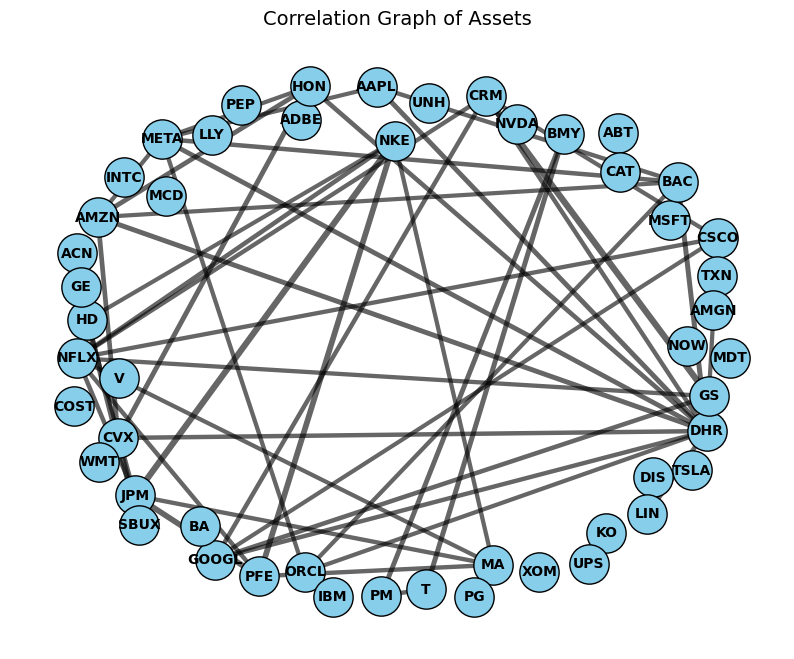


Number of nodes: 50, edges: 47


In [59]:
# ===============================================
# 2) Build Correlation Graph
# ===============================================
threshold = 0.6
G = nx.Graph()
G.add_nodes_from(assets)

for i in range(len(assets)):
    for j in range(i + 1, len(assets)):
        w = abs(corr_matrix.iloc[i, j])
        if w > threshold:
            G.add_edge(assets[i], assets[j], weight=w)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, weight='weight', k=5)
edges = G.edges(data=True)
weights = [d['weight'] * 5 for (_, _, d) in edges]

nx.draw_networkx_nodes(G, pos, node_size=800, node_color="skyblue", edgecolors='k')
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
plt.title("Correlation Graph of Assets", fontsize=14)
plt.axis("off")
plt.show()

print(f"\nNumber of nodes: {len(G.nodes())}, edges: {len(G.edges())}")


Detected 31 communities.
Community 3: ['AAPL', 'AMZN', 'META', 'CVX', 'BAC', 'ORCL', 'DHR', 'HON', 'LIN']
Community 1: ['MSFT']
Community 2: ['GOOGL', 'CSCO', 'CRM', 'GS']
Community 4: ['NVDA']
Community 5: ['TSLA']
Community 6: ['JPM', 'MA', 'HD', 'PFE', 'NFLX', 'NKE', 'SBUX']
Community 7: ['V']
Community 8: ['XOM']
Community 9: ['UNH']
Community 10: ['PG']
Community 11: ['KO']
Community 12: ['PEP']
Community 13: ['DIS']
Community 14: ['INTC']
Community 15: ['ADBE']
Community 16: ['T', 'BMY', 'PM']
Community 17: ['ABT']
Community 18: ['WMT']
Community 19: ['COST']
Community 20: ['MCD']
Community 21: ['LLY']
Community 22: ['ACN']
Community 23: ['UPS']
Community 24: ['TXN']
Community 25: ['IBM']
Community 26: ['BA']
Community 27: ['CAT']
Community 28: ['MDT']
Community 29: ['GE']
Community 30: ['AMGN']
Community 0: ['NOW']


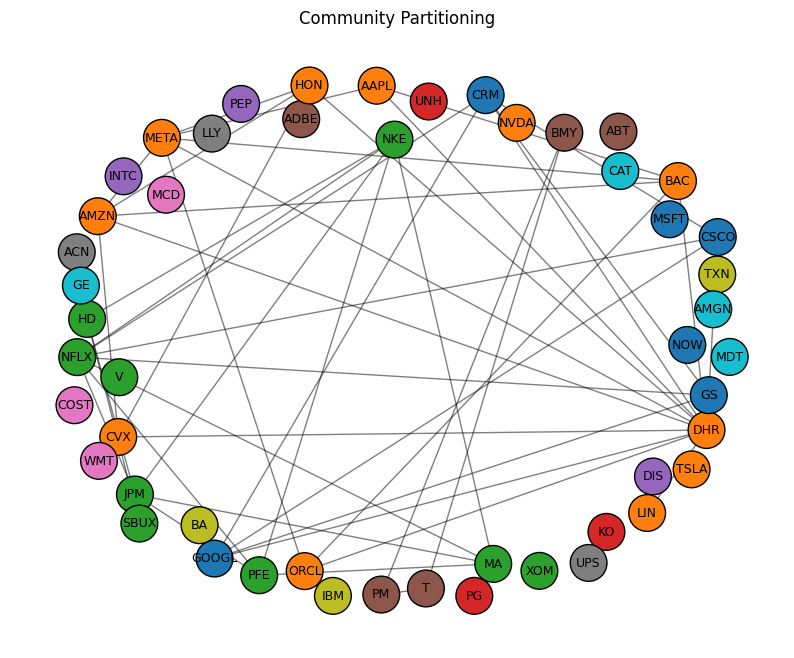

In [60]:
# ===============================================
# 3) Community Detection (Louvain)
# ===============================================
import community as community_louvain
import matplotlib.cm as cm

community_method = "louvain"

if community_method == "louvain":
    partition = community_louvain.best_partition(G)
else:
    from networkx.algorithms import community as nx_comm
    comms = list(nx_comm.spectral_clustering(G, k=min(4, len(G))))
    partition = {node: comms[i] for i, node in enumerate(G.nodes())}

# Group nodes by community
communities = {}
for node, cid in partition.items():
    communities.setdefault(cid, []).append(node)

print(f"Detected {len(communities)} communities.")
for cid, nodelist in communities.items():
    print(f"Community {cid}: {nodelist}")

# --- Visualization ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, weight='weight', k=5)
cmap = plt.colormaps.get_cmap("tab10")

unique_cids = sorted(communities.keys())
cid_to_idx = {cid: idx for idx, cid in enumerate(unique_cids)}
colors = [cmap(cid_to_idx[partition[n]] / max(1, len(unique_cids) - 1)) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=700, edgecolors='k')
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title("Community Partitioning")
plt.axis("off")
plt.show()


In [61]:
# ===============================================
# 4) QAOA Control Parameters
# ===============================================
A = 4.0
B = 8.0
p = 3                     # QAOA depth
qaoa_max_n = 12           # Max nodes per subproblem
n_restarts = 3
seed = 42

print(f"QAOA max nodes per community: {qaoa_max_n}")


QAOA max nodes per community: 12


In [62]:
# ===============================================
# 5) Community Preprocessing
# ===============================================
def greedy_preselect(G_sub, k=12):
    """Greedy node selection based on degree + clustering centrality."""
    metrics = {}
    deg_c = nx.degree_centrality(G_sub)
    clus_c = nx.clustering(G_sub)
    for n in G_sub.nodes():
        metrics[n] = deg_c[n] + clus_c[n]
    top_nodes = sorted(metrics, key=metrics.get, reverse=True)[:k]
    return G_sub.subgraph(top_nodes).copy()

community_results = {}

for cid, nodes_c in communities.items():
    G_sub = G.subgraph(nodes_c).copy()
    if len(G_sub) <= qaoa_max_n:
        community_results[cid] = {"graph": G_sub, "method": "direct"}
        print(f"Community {cid}: {len(G_sub)} nodes → QAOA directly.")
    else:
        G_red = greedy_preselect(G_sub, k=qaoa_max_n)
        community_results[cid] = {"graph": G_red, "method": "reduced"}
        print(f"Community {cid}: reduced from {len(G_sub)}→{len(G_red)} nodes.")


Community 3: 9 nodes → QAOA directly.
Community 1: 1 nodes → QAOA directly.
Community 2: 4 nodes → QAOA directly.
Community 4: 1 nodes → QAOA directly.
Community 5: 1 nodes → QAOA directly.
Community 6: 7 nodes → QAOA directly.
Community 7: 1 nodes → QAOA directly.
Community 8: 1 nodes → QAOA directly.
Community 9: 1 nodes → QAOA directly.
Community 10: 1 nodes → QAOA directly.
Community 11: 1 nodes → QAOA directly.
Community 12: 1 nodes → QAOA directly.
Community 13: 1 nodes → QAOA directly.
Community 14: 1 nodes → QAOA directly.
Community 15: 1 nodes → QAOA directly.
Community 16: 3 nodes → QAOA directly.
Community 17: 1 nodes → QAOA directly.
Community 18: 1 nodes → QAOA directly.
Community 19: 1 nodes → QAOA directly.
Community 20: 1 nodes → QAOA directly.
Community 21: 1 nodes → QAOA directly.
Community 22: 1 nodes → QAOA directly.
Community 23: 1 nodes → QAOA directly.
Community 24: 1 nodes → QAOA directly.
Community 25: 1 nodes → QAOA directly.
Community 26: 1 nodes → QAOA direc

In [63]:
# ===============================================
# 6) QAOA Runner (Corrected)
# ===============================================
def run_qaoa_on_subgraph(G_sub, A=4.0, B=2.0, p_max=1, restarts=3, warm_start=None,
                         opt_steps=100, seed_local=42):
    """Runs QAOA on a subgraph with given depth p_max."""
    p = int(p_max)
    nodes = list(G_sub.nodes())
    n = len(nodes)
    if n == 0:
        return np.array([]), np.inf

    # --- Build QUBO ---
    G_comp = nx.complement(G_sub)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = -A
    for i in range(n):
        for j in range(i + 1, n):
            if G_comp.has_edge(nodes[i], nodes[j]):
                Q[i, j] = Q[j, i] = B

    row_sums = Q.sum(axis=1)
    h = np.zeros(n)
    J = np.zeros((n, n))
    for i in range(n):
        h[i] = -0.5 * Q[i, i] - 0.25 * (row_sums[i] - Q[i, i])
        for j in range(i + 1, n):
            J[i, j] = J[j, i] = 0.25 * Q[i, j]

    # --- Build Hamiltonian ---
    coeffs, obs = [], []
    for i in range(n):
        coeffs.append(float(h[i]))
        obs.append(qml.PauliZ(wires=i))
    for i in range(n):
        for j in range(i + 1, n):
            if abs(J[i, j]) > 1e-12:
                coeffs.append(float(J[i, j]))
                obs.append(qml.PauliZ(wires=i) @ qml.PauliZ(wires=j))
    H = qml.Hamiltonian(coeffs, obs)

    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev, interface="autograd")
    def circuit(params):
        params = np.array(params).ravel()
        if params.size < 2 * p:
            params = np.concatenate([params, np.zeros(2 * p - params.size)])
        gammas = params[:p]
        betas = params[p:2*p]
        for i in range(n):
            qml.Hadamard(wires=i)
        for layer in range(p):
            for i in range(n):
                qml.RZ(2.0 * h[i] * gammas[layer], wires=i)
            for i in range(n):
                for j in range(i + 1, n):
                    if abs(J[i, j]) > 1e-12:
                        qml.IsingZZ(2.0 * J[i, j] * gammas[layer], wires=[i, j])
            for i in range(n):
                qml.RX(2.0 * betas[layer], wires=i)
        return qml.expval(H)

    rng = np.random.default_rng(seed_local)
    best_params, best_energy = None, np.inf
    param_len = 2 * p

    for r in range(restarts):
        params = rng.uniform(0.0, 0.1, size=(param_len,))
        if warm_start is not None:
            ws = np.array(warm_start).ravel()
            ncopy = min(len(ws), param_len)
            params[:ncopy] = ws[:ncopy]
        opt = qml.AdamOptimizer(stepsize=0.01)
        for _ in range(opt_steps):
            params, _ = opt.step_and_cost(circuit, params)
        final_e = float(circuit(params))
        if final_e < best_energy:
            best_energy, best_params = final_e, params.copy()

    if best_params is None:
        return np.array([]), np.inf
    return np.array(best_params).ravel(), float(best_energy)


In [64]:
# ===============================================
# 7) Robust Sampling Helper (Defined before Layerwise use)
# ===============================================
def sample_best_bitstring_for_subgraph(G_sub, params, p_layer=None, shots_sample=1000, seed_local=123):
    if params is None:
        return ""
    params = np.array(params).ravel()
    if params.size == 0:
        return ""
    if p_layer is None:
        p_layer = params.size // 2
    p = int(p_layer)
    if p <= 0:
        return ""

    nodes = list(G_sub.nodes())
    n = len(nodes)
    if n == 0:
        return ""

    G_comp = nx.complement(G_sub)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = -A
    for i in range(n):
        for j in range(i + 1, n):
            if G_comp.has_edge(nodes[i], nodes[j]):
                Q[i, j] = Q[j, i] = B
    row_sums = Q.sum(axis=1)
    h = np.zeros(n)
    J = np.zeros((n, n))
    for i in range(n):
        h[i] = -0.5 * Q[i, i] - 0.25 * (row_sums[i] - Q[i, i])
        for j in range(i + 1, n):
            J[i, j] = J[j, i] = 0.25 * Q[i, j]

    dev_s = qml.device("default.qubit", wires=n, shots=shots_sample)

    @qml.qnode(dev_s)
    def sample_qnode(params_sample):
        params_sample = np.array(params_sample).ravel()
        if params_sample.size < 2 * p:
            params_sample = np.concatenate([params_sample, np.zeros(2 * p - params_sample.size)])
        gammas = params_sample[:p]
        betas = params_sample[p:2*p]
        for i in range(n):
            qml.Hadamard(wires=i)
        for layer in range(p):
            for i in range(n):
                qml.RZ(2.0 * h[i] * gammas[layer], wires=i)
            for i in range(n):
                for j in range(i + 1, n):
                    if abs(J[i, j]) > 1e-12:
                        qml.IsingZZ(2.0 * J[i, j] * gammas[layer], wires=[i, j])
            for i in range(n):
                qml.RX(2.0 * betas[layer], wires=i)
        return qml.sample(wires=range(n))

    samples_raw = np.array(sample_qnode(params))
    if samples_raw.size == 0:
        return ""

    if samples_raw.ndim == 1 and samples_raw.size == n:
        samples = samples_raw.reshape(1, n)
    else:
        samples = samples_raw.reshape(-1, n)

    bitstrings = []
    for s in samples:
        bits = [str(int(round(float(b)))) for b in s]
        bitstrings.append("".join(bits))

    uniq, cnts = np.unique(bitstrings, return_counts=True)
    best = uniq[np.argmax(cnts)]
    return best


In [65]:
# ===============================================
# 8) Layerwise QAOA per Community (Verbose Diagnostics)
# ===============================================
community_solutions = {}
community_progress = {}  # store intermediate info

for cid, entry in community_results.items():
    G_sub = entry["graph"]
    print(f"\n=== 🧩 Community {cid} ({len(G_sub)} nodes) ===")
    print(f"Nodes: {list(G_sub.nodes())}\n{'-'*60}")

    warm_params = None
    progress_layers = []

    for p_layer in range(1, p + 1):
        print(f"▶ Layer depth p={p_layer}")
        params, energy = run_qaoa_on_subgraph(G_sub,
                                              A=A, B=B,
                                              p_max=p_layer,
                                              restarts=n_restarts,
                                              warm_start=warm_params,
                                              opt_steps=80,
                                              seed_local=seed)
        warm_params = params.copy()

        best_bs = sample_best_bitstring_for_subgraph(G_sub, params, p_layer=p_layer, shots_sample=1000)
        if best_bs != "":
            selected_nodes = [n for n, b in zip(G_sub.nodes(), best_bs) if b == "1"]
        else:
            selected_nodes = []

        progress_layers.append({
            "layer": p_layer,
            "energy": energy,
            "bitstring": best_bs,
            "selected": selected_nodes
        })

        print(f"  Energy: {energy:.6f}")
        print(f"  Bitstring: {best_bs}")
        print(f"  Selected nodes: {selected_nodes}")
        print("-"*60)

    community_progress[cid] = progress_layers
    community_solutions[cid] = {"params": warm_params, "energy": energy}

print("\n=== Summary of Layerwise Results ===")
for cid, logs in community_progress.items():
    print(f"\nCommunity {cid}:")
    for entry in logs:
        print(f"  p={entry['layer']} → E={entry['energy']:.4f}, Selected={entry['selected']}")



=== 🧩 Community 3 (9 nodes) ===
Nodes: ['CVX', 'AAPL', 'BAC', 'LIN', 'HON', 'AMZN', 'ORCL', 'DHR', 'META']
------------------------------------------------------------
▶ Layer depth p=1
  Energy: -22.152564
  Bitstring: 000000010
  Selected nodes: ['DHR']
------------------------------------------------------------
▶ Layer depth p=2
  Energy: -24.358378
  Bitstring: 000000010
  Selected nodes: ['DHR']
------------------------------------------------------------
▶ Layer depth p=3
  Energy: -26.590350
  Bitstring: 100011010
  Selected nodes: ['CVX', 'HON', 'AMZN', 'DHR']
------------------------------------------------------------

=== 🧩 Community 1 (1 nodes) ===
Nodes: ['MSFT']
------------------------------------------------------------
▶ Layer depth p=1
  Energy: -1.998618
  Bitstring: 1
  Selected nodes: ['MSFT']
------------------------------------------------------------
▶ Layer depth p=2
  Energy: -1.999728
  Bitstring: 1
  Selected nodes: ['MSFT']
-------------------------------

Community 3 best selected nodes: ['CVX', 'HON', 'AMZN', 'DHR']
Community 1 best selected nodes: ['MSFT']
Community 2 best selected nodes: ['CSCO', 'CRM', 'GS', 'GOOGL']
Community 4 best selected nodes: ['NVDA']
Community 5 best selected nodes: ['TSLA']
Community 6 best selected nodes: ['PFE', 'NFLX', 'NKE', 'JPM', 'MA']
Community 7 best selected nodes: ['V']
Community 8 best selected nodes: ['XOM']
Community 9 best selected nodes: ['UNH']
Community 10 best selected nodes: ['PG']
Community 11 best selected nodes: ['KO']
Community 12 best selected nodes: ['PEP']
Community 13 best selected nodes: ['DIS']
Community 14 best selected nodes: ['INTC']
Community 15 best selected nodes: ['ADBE']
Community 16 best selected nodes: ['T', 'BMY', 'PM']
Community 17 best selected nodes: ['ABT']
Community 18 best selected nodes: ['WMT']
Community 19 best selected nodes: ['COST']
Community 20 best selected nodes: ['MCD']
Community 21 best selected nodes: ['LLY']
Community 22 best selected nodes: ['ACN']

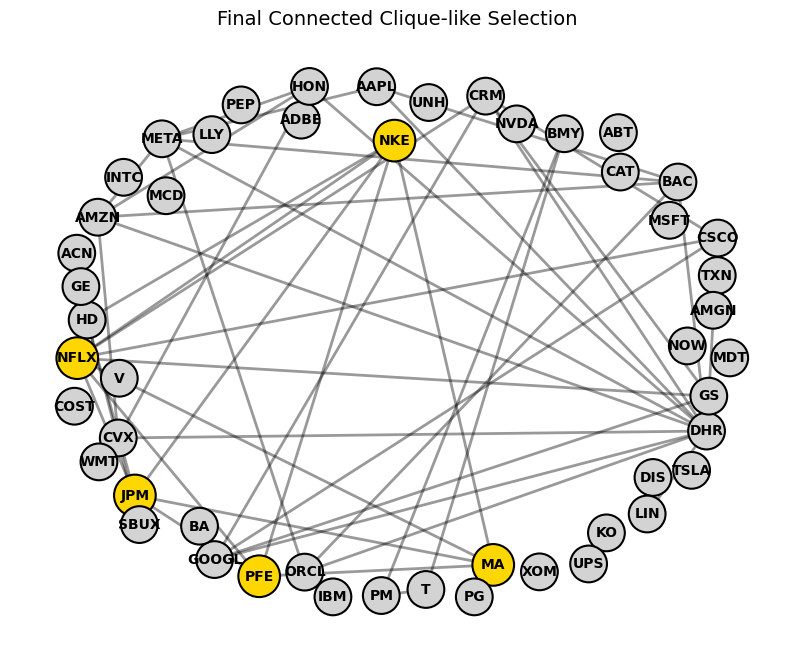

In [66]:
# ===============================================
# 9) Final Selection & Visualization
# ===============================================
selected_by_community = {}
for cid, entry in community_results.items():
    G_sub = entry["graph"]
    params = community_solutions.get(cid, {}).get("params", None)
    best_bs = sample_best_bitstring_for_subgraph(G_sub, params, p_layer=len(params)//2 if params is not None else 0, shots_sample=1000)
    if best_bs == "":
        continue
    selected = [n for n, b in zip(G_sub.nodes(), best_bs) if b == "1"]
    selected_by_community[cid] = selected
    print(f"Community {cid} best selected nodes: {selected}")

if not selected_by_community:
    print("⚠️ No community produced a valid selection.")
    final_selection = []
else:
    largest_cid = max(selected_by_community, key=lambda k: len(selected_by_community[k]))
    largest_selection = selected_by_community[largest_cid]
    G_largest = G.subgraph(largest_selection)
    connected_components = list(nx.connected_components(G_largest))
    final_selection = max(connected_components, key=len) if connected_components else largest_selection

print(f"\n✅ Largest connected clique-like subset: {final_selection}")

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, weight='weight', k=5)

node_colors = [
    "gold" if node in final_selection else "lightgray"
    for node in G.nodes()
]
node_sizes = [900 if node in final_selection else 700 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='k', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Final Connected Clique-like Selection", fontsize=14)
plt.axis("off")
plt.show()
